In [1]:
import pandas as pd
import numpy as np

In [7]:
def f1_score(Y_true, Y_pred):
    f1s=[]
    for label in np.unique(Y_true):
        tp=np.sum((Y_pred==label) & (Y_true==label))
        fp=np.sum((Y_pred==label) & (Y_true!=label))
        fn=np.sum((Y_pred!=label) & (Y_true==label))
        
        precision = tp/(tp+fp) if (tp+fp) > 0 else 0
        recall = tp/(tp+fn) if (tp+fn) > 0 else 0
        f1 = 2 *precision*recall/(precision+recall) if (precision+recall) > 0 else 0
        f1s.append(f1)
    
    return np.mean(f1s)

In [2]:

def knn_predict(X_train, Y_train, test_point, k):
    distances=np.sqrt(np.sum((X_train.values - test_point.values)**2, axis=1))
    k_indices=np.argsort(distances)[:k]
    knn_labels=Y_train.iloc[k_indices]
    return knn_labels.value_counts().index[0]

def knn_accuracy(X_train, Y_train, X_test, Y_test, k):
    correct=0
    for i in range(len(X_test)):
        value=knn_predict(X_train, Y_train, X_test.iloc[i], k)
        if value==Y_test.iloc[i]:
            correct+=1
    return correct/len(X_test) 

In [3]:
#Returns predictions for all the test points
def knn_predictions(X_train, Y_train, X_test, k):
    predictions=[]
    for i in range(len(X_test)):
        pred=knn_predict(X_train, Y_train, X_test.iloc[i], k)
        predictions.append(pred)
    return np.array(predictions) 

In [4]:
#Stratified K-Fold split
def stratified_k_fold(Y, k=10):
    folds=[[] for _ in range(k)]
    
    for label in Y.unique():
        indices=np.where(Y==label)[0]
        np.random.shuffle(indices)
        for i, idx in enumerate(indices):
            folds[i%k].append(idx)
    
    return folds 

In [19]:
#Full evaluation that runs KNN with 10-fold CV and returns average accuracy and F1
def evaluate_knn(X, Y, k_value, n_folds=10):
    np.random.seed(67)  
    folds=stratified_k_fold(Y, n_folds)
    accuracies=[]
    f1_scores=[]
    
    for i in range(n_folds):
        test_idx=folds[i]
        train_idx =[idx for j in range(n_folds) if j!=i for idx in folds[j]]
        
        X_train, X_test=X.iloc[train_idx], X.iloc[test_idx]
        Y_train, Y_test=Y.iloc[train_idx], Y.iloc[test_idx]
        
        #Normalization
        train_min=X_train.min()
        train_max=X_train.max()
        X_train_norm=(X_train-train_min)/(train_max-train_min)
        X_test_norm=(X_test-train_min)/(train_max-train_min)
        X_train_norm = X_train_norm.fillna(0)
        X_test_norm = X_test_norm.fillna(0)
        
        #Getting the predictions
        preds=knn_predictions(X_train_norm, Y_train, X_test_norm, k_value)
        
        #Compute accuracy and F1
        acc=np.sum(preds==Y_test.values)/len(Y_test)
        f1=f1_score(Y_test.values, preds)
        
        accuracies.append(acc)
        f1_scores.append(f1)
    
    return np.mean(accuracies), np.mean(f1_scores)

In [20]:
#Running KNN on Rice dataset
data=pd.read_csv("preprocessed_datasets/rice_processed.csv")
X=data.iloc[:, :-1]
Y=data.iloc[:, -1]

k_values=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

for k in k_values:
    acc, f1=evaluate_knn(X, Y, k_value=k)
    print(f"k={k}: Accuracy={acc:.4f}, F1={f1:.4f}")
    
    

k=1: Accuracy=0.8861, F1=0.8838
k=3: Accuracy=0.9100, F1=0.9080
k=5: Accuracy=0.9220, F1=0.9203
k=7: Accuracy=0.9210, F1=0.9192
k=9: Accuracy=0.9226, F1=0.9209
k=11: Accuracy=0.9252, F1=0.9236
k=13: Accuracy=0.9247, F1=0.9230
k=15: Accuracy=0.9241, F1=0.9224
k=17: Accuracy=0.9260, F1=0.9243
k=19: Accuracy=0.9276, F1=0.9259
k=21: Accuracy=0.9257, F1=0.9240


In [21]:
#Running KNN on Parkinsons dataset
data=pd.read_csv("preprocessed_datasets/parkinsons_processed.csv")
X=data.iloc[:, :-1]
Y=data.iloc[:, -1]

k_values=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

for k in k_values:
    acc, f1=evaluate_knn(X, Y, k_value=k)
    print(f"k={k}: Accuracy={acc:.4f}, F1={f1:.4f}")

k=1: Accuracy=0.9589, F1=0.9456
k=3: Accuracy=0.9439, F1=0.9277
k=5: Accuracy=0.9386, F1=0.9151
k=7: Accuracy=0.9342, F1=0.9048
k=9: Accuracy=0.8981, F1=0.8432
k=11: Accuracy=0.8828, F1=0.8133
k=13: Accuracy=0.8778, F1=0.7771
k=15: Accuracy=0.8628, F1=0.7466
k=17: Accuracy=0.8570, F1=0.7112
k=19: Accuracy=0.8462, F1=0.6846
k=21: Accuracy=0.8464, F1=0.6875


In [22]:
#Running KNN on Digits dataset
data=pd.read_csv("preprocessed_datasets/digits_processed.csv")
X=data.iloc[:, :-1]
Y=data.iloc[:, -1]

k_values=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

for k in k_values:
    acc, f1 = evaluate_knn(X, Y, k_value=k)
    print(f"k={k}: Accuracy={acc:.4f}, F1={f1:.4f}")

k=1: Accuracy=0.9866, F1=0.9866
k=3: Accuracy=0.9866, F1=0.9866
k=5: Accuracy=0.9872, F1=0.9872
k=7: Accuracy=0.9833, F1=0.9832
k=9: Accuracy=0.9833, F1=0.9832
k=11: Accuracy=0.9816, F1=0.9816
k=13: Accuracy=0.9800, F1=0.9798
k=15: Accuracy=0.9777, F1=0.9776
k=17: Accuracy=0.9783, F1=0.9781
k=19: Accuracy=0.9778, F1=0.9776
k=21: Accuracy=0.9728, F1=0.9725


In [23]:
#Running KNN on Student Dropout dataset
data=pd.read_csv("preprocessed_datasets/student_dropout_processed.csv")
X=data.iloc[:, :-1]
Y=data.iloc[:, -1]

k_values=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

for k in k_values:
    acc, f1 = evaluate_knn(X, Y, k_value=k)
    print(f"k={k}: Accuracy={acc:.4f}, F1={f1:.4f}") 

k=1: Accuracy=0.5375, F1=0.4673
k=3: Accuracy=0.5773, F1=0.4907
k=5: Accuracy=0.5922, F1=0.4916
k=7: Accuracy=0.6065, F1=0.4978
k=9: Accuracy=0.6187, F1=0.4999
k=11: Accuracy=0.6169, F1=0.4918
k=13: Accuracy=0.6191, F1=0.4876
k=15: Accuracy=0.6175, F1=0.4775
k=17: Accuracy=0.6207, F1=0.4741
k=19: Accuracy=0.6153, F1=0.4657
k=21: Accuracy=0.6141, F1=0.4584


In [24]:
#Running KNN on Credit Approval dataset
data=pd.read_csv("preprocessed_datasets/credit_processed.csv")
X=data.iloc[:, :-1]
Y=data.iloc[:, -1]

k_values=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

for k in k_values:
    acc, f1 = evaluate_knn(X, Y, k_value=k)
    print(f"k={k}: Accuracy={acc:.4f}, F1={f1:.4f}")

k=1: Accuracy=0.8221, F1=0.8199
k=3: Accuracy=0.8542, F1=0.8524
k=5: Accuracy=0.8618, F1=0.8601
k=7: Accuracy=0.8666, F1=0.8651
k=9: Accuracy=0.8711, F1=0.8698
k=11: Accuracy=0.8665, F1=0.8652
k=13: Accuracy=0.8681, F1=0.8666
k=15: Accuracy=0.8572, F1=0.8556
k=17: Accuracy=0.8618, F1=0.8603
k=19: Accuracy=0.8618, F1=0.8603
k=21: Accuracy=0.8588, F1=0.8573


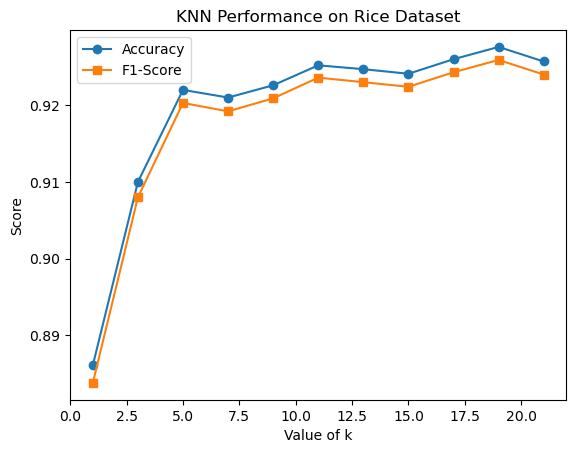

In [ ]:
import matplotlib.pyplot as plt

#Rice
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
rice_acc = [0.8861, 0.9100, 0.9220, 0.9210, 0.9226, 0.9252, 0.9247, 0.9241, 0.9260, 0.9276, 0.9257]
rice_f1 = [0.8838, 0.9080, 0.9203, 0.9192, 0.9209, 0.9236, 0.9230, 0.9224, 0.9243, 0.9259, 0.9240]

plt.figure()
plt.plot(k_values, rice_acc, marker='o', label='Accuracy')
plt.plot(k_values, rice_f1, marker='s', label='F1-Score')
plt.xlabel('Value of k')
plt.ylabel('Score')
plt.title('KNN Performance on Rice Dataset')
plt.legend()
plt.savefig('graphs/rice_knn.png')
plt.show()

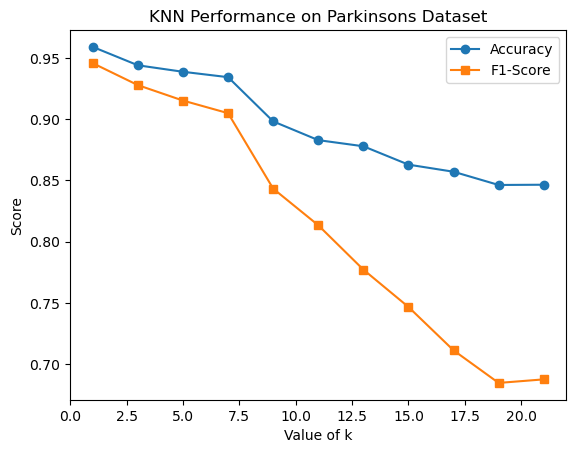

In [26]:
#Parkinsons
park_acc = [0.9589, 0.9439, 0.9386, 0.9342, 0.8981, 0.8828, 0.8778, 0.8628, 0.8570, 0.8462, 0.8464]
park_f1 = [0.9456, 0.9277, 0.9151, 0.9048, 0.8432, 0.8133, 0.7771, 0.7466, 0.7112, 0.6846, 0.6875]

plt.figure()
plt.plot(k_values, park_acc, marker='o', label='Accuracy')
plt.plot(k_values, park_f1, marker='s', label='F1-Score')
plt.xlabel('Value of k')
plt.ylabel('Score')
plt.title('KNN Performance on Parkinsons Dataset')
plt.legend()
plt.savefig('graphs/parkinsons_knn.png')
plt.show()

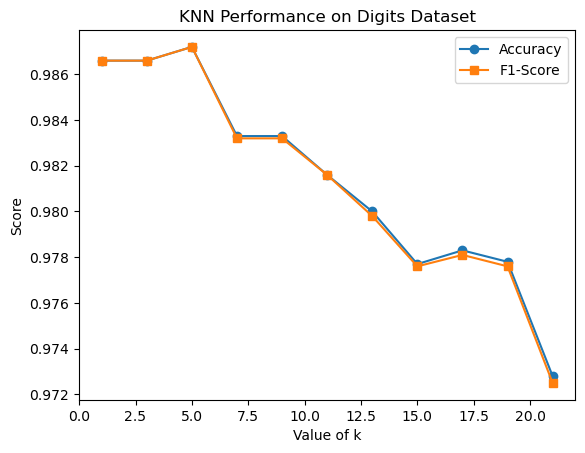

In [27]:
#Digits
dig_acc = [0.9866, 0.9866, 0.9872, 0.9833, 0.9833, 0.9816, 0.9800, 0.9777, 0.9783, 0.9778, 0.9728]
dig_f1 = [0.9866, 0.9866, 0.9872, 0.9832, 0.9832, 0.9816, 0.9798, 0.9776, 0.9781, 0.9776, 0.9725]

plt.figure()
plt.plot(k_values, dig_acc, marker='o', label='Accuracy')
plt.plot(k_values, dig_f1, marker='s', label='F1-Score')
plt.xlabel('Value of k')
plt.ylabel('Score')
plt.title('KNN Performance on Digits Dataset')
plt.legend()
plt.savefig('graphs/digits_knn.png')
plt.show()

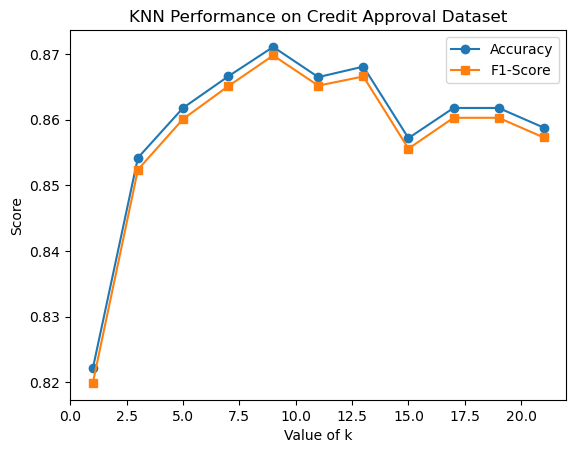

In [28]:
#Credit Approval
cred_acc = [0.8221, 0.8542, 0.8618, 0.8666, 0.8711, 0.8665, 0.8681, 0.8572, 0.8618, 0.8618, 0.8588]
cred_f1 = [0.8199, 0.8524, 0.8601, 0.8651, 0.8698, 0.8652, 0.8666, 0.8556, 0.8603, 0.8603, 0.8573]

plt.figure()
plt.plot(k_values, cred_acc, marker='o', label='Accuracy')
plt.plot(k_values, cred_f1, marker='s', label='F1-Score')
plt.xlabel('Value of k')
plt.ylabel('Score')
plt.title('KNN Performance on Credit Approval Dataset')
plt.legend()
plt.savefig('graphs/credit_knn.png')
plt.show()

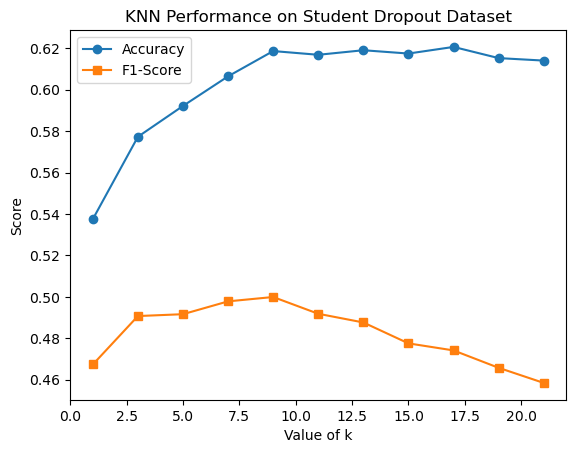

In [29]:
#Student Dropout
stud_acc = [0.5375, 0.5773, 0.5922, 0.6065, 0.6187, 0.6169, 0.6191, 0.6175, 0.6207, 0.6153, 0.6141]
stud_f1 = [0.4673, 0.4907, 0.4916, 0.4978, 0.4999, 0.4918, 0.4876, 0.4775, 0.4741, 0.4657, 0.4584]

plt.figure()
plt.plot(k_values, stud_acc, marker='o', label='Accuracy')
plt.plot(k_values, stud_f1, marker='s', label='F1-Score')
plt.xlabel('Value of k')
plt.ylabel('Score')
plt.title('KNN Performance on Student Dropout Dataset')
plt.legend()
plt.savefig('graphs/student_dropout_knn.png')
plt.show()